# Régression par Arbre de Décision (Decision Tree Regressor)

## Introduction

Un **arbre de décision pour la régression** est un modèle prédictif qui divise les données en sous-groupes selon des règles conditionnelles, afin de prédire une **valeur continue** (ici, l'élévation d'une randonnée). À chaque nœud, l'arbre choisit la meilleure séparation en minimisant une **fonction de perte (Loss Function)**, généralement l'**erreur quadratique moyenne** (MSE — *Mean Squared Error*).

---

## Loss Function : Mean Squared Error (MSE)

La MSE mesure la qualité d’une prédiction en calculant la moyenne des carrés des écarts entre les valeurs réelles et la moyenne du groupe :

$$ \text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \bar{y})^2 $$

où :
- yᵢ est une valeur réelle,
- ȳ est la moyenne des \( y_i \),
- n est le nombre d'exemples dans le nœud.



## Jeu de Données

| âge | de_grenoble? | en_weekend? | élévation (km) |
|-----|--------------|-------------|----------------|
| 22  | 0            | 1           | 0.5            |
| 24  | 0            | 1           | 0.15           |
| 29  | 1            | 1           | 1.2            |
| 31  | 1            | 1           | 1.4            |
| 35  | 1            | 0           | 0.7            |
| 40  | 1            | 1           | 1.6            |
| 21  | 0            | 1           | 0.6            |
| 26  | 0            | 0           | 0.2            |
| 45  | 1            | 0           | 0.9            |
| 30  | 0            | 1           | 0.4            |

---

## Construction de l’Arbre de Profondeur 2

### Étape 1 — Racine : Séparation sur `de_grenoble?`

- **Branche `de_grenoble? = 1`** : [1.2, 1.4, 0.7, 1.6, 0.9]  
  - Moyenne = 1.16  
  - MSE =  
    $$
    \frac{1}{5} \left[(1.2 - 1.16)^2 + (1.4 - 1.16)^2 + (0.7 - 1.16)^2 + (1.6 - 1.16)^2 + (0.9 - 1.16)^2 \right] = 0.106
    $$
  
- **Branche `de_grenoble? = 0`** : [0.5, 0.15, 0.6, 0.2, 0.4]  
  - Moyenne = 0.37  
  - MSE =  
    $$
    \frac{1}{5} \left[(0.5 - 0.37)^2 + (0.15 - 0.37)^2 + (0.6 - 0.37)^2 + (0.2 - 0.37)^2 + (0.4 - 0.37)^2 \right] = 0.03
    $$

- **MSE globale (pondérée)** :  
$$
\frac{5}{10} \times 0.108 + \frac{5}{10} \times 0.029 = 0.068
$$

---

### Étape 2 — Sous-arbre pour `de_grenoble? = 1` : Séparation sur `en_weekend?`

#### Données :

| élévation (km) | en_weekend? |
|----------------|-------------|
| 1.2            | 1           |
| 1.4            | 1           |
| 0.7            | 0           |
| 1.6            | 1           |
| 0.9            | 0           |

- `en_weekend? = 1` → [1.2, 1.4, 1.6]  
  - Moyenne = 1.4  
  - MSE = 0.027  
- `en_weekend? = 0` → [0.7, 0.9]  
  - Moyenne = 0.8  
  - MSE = 0.01  

- **MSE pondérée (branche `de_grenoble? = 1`)** :  
$$
\frac{3}{5} \times 0.027 + \frac{2}{5} \times 0.01 = 0.0202
$$

---

### Étape 2 — Sous-arbre pour `de_grenoble? = 0` : Séparation sur `âge ≤ 25`

#### Données :

| âge | élévation |
|-----|-----------|
| 22  | 0.5       |
| 24  | 0.15      |
| 21  | 0.6       |
| 26  | 0.2       |
| 30  | 0.4       |

- `âge ≤ 25` → [0.5, 0.15, 0.6]  
  - Moyenne = 0.42  
  - MSE = 0.037  
- `âge > 25` → [0.2, 0.4]  
  - Moyenne = 0.3  
  - MSE = 0.01  

- **MSE pondérée (branche `de_grenoble? = 0`)** :  
$$
\frac{3}{5} \times 0.037 + \frac{2}{5} \times 0.01 = 0.0262
$$

---

## MSE Finale de l’Arbre (Profondeur = 2)

$$
\frac{5}{10} \times 0.0202 + \frac{5}{10} \times 0.0262 = \boxed{0.0232}
$$

---
## Arbre de Décision (Profondeur = 2)

                         [de_grenoble??]
                         /             \
                      oui               non
                    /                     \
           [en_weekend?]            [âge ≤ 25?]
             /        \               /        \
       oui            non       oui            non
    (M=1.4)        (M=0.8)    (M=0.42)        (M=0.3)

---
## Questions
- Que se passe-t-il si l’on utilise **ville** avec {Grenoble, Lyon, Saint-Étienne} au lieu de **de_grenoble** ?
- Problèmes potentiels?
- Selon vous, quels pourraient être les **critères d’arrêt** ?

---
## Conclusion

L’arbre de décision avec une profondeur de 2 permet une **forte réduction de la MSE** comparée à une seule séparation. Il apprend à séparer les groupes selon les caractéristiques les plus pertinentes (ici `de_grenoble?`, `en_weekend?`, et `âge`).

---

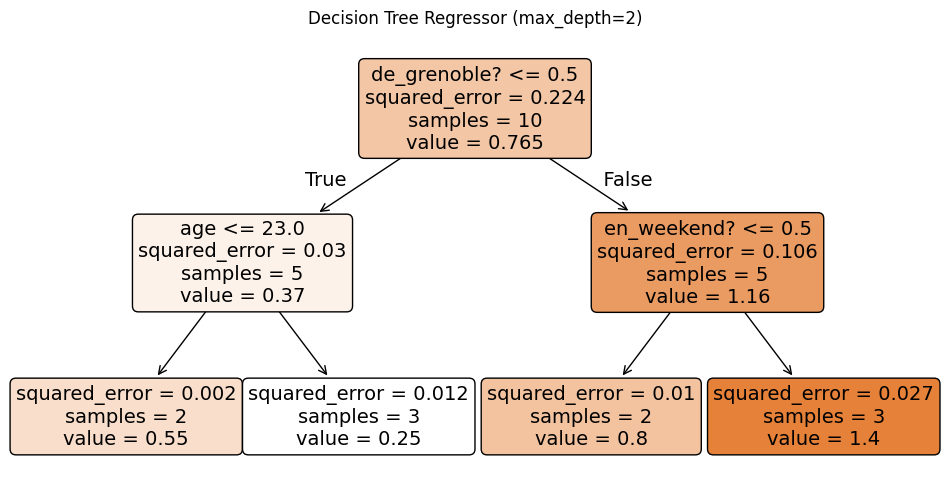

In [31]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

# Data
data = {
    'age': [22, 24, 29, 31, 35, 40, 21, 26, 45, 30],
    'de_grenoble?': [0, 0, 1, 1, 1, 1, 0, 0, 1, 0],
    'en_weekend?': [1, 1, 1, 1, 0, 1, 1, 0, 0, 1],
    'élévation': [0.5, 0.15, 1.2, 1.4, 0.7, 1.6, 0.6, 0.2, 0.9, 0.4]
}

df = pd.DataFrame(data)

# Features and target
X = df[['age', 'de_grenoble?', 'en_weekend?']]
y = df['élévation']

# Train the decision tree regressor
model = DecisionTreeRegressor(max_depth=2)
model.fit(X, y)

# Plot the tree
plt.figure(figsize=(12, 6))
plot_tree(model, feature_names=X.columns, filled=True, rounded=True)
plt.title("Decision Tree Regressor (max_depth=2)")
plt.show()